# FA (NIPFA) - beer dataset

In [1]:
#disable warnings
from warnings import simplefilter, filterwarnings
simplefilter(action='ignore', category=FutureWarning)
filterwarnings("ignore")

## beer dataset

In [2]:
# beer dataset
from scientisttools.datasets import beer
beer

,cost,size,alcohol,reputat,color,aroma,taste,rnd1,rnd2,rnd3,rnd4,rnd5,rnd6,rnd7
0,10,15,20,85,40,30,50,40,80,65,25,90,45,40
1,100,70,50,30,75,60,80,70,55,45,25,95,95,60
2,65,30,35,80,80,60,90,45,90,65,90,20,95,35
3,0,0,20,30,80,90,100,85,30,45,85,40,80,5
4,10,25,10,100,50,40,60,20,5,25,25,20,25,80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,10,25,10,100,50,40,60,50,85,60,50,75,30,85
95,25,35,30,40,45,30,65,80,80,55,0,35,95,80
96,5,10,15,65,50,65,85,85,50,95,50,35,10,95
97,20,5,10,40,60,50,95,5,90,65,65,50,65,10


## Instanciation & training

In [3]:
#unrotated NIPFA
from scientisttools import FA
clf = FA(ncp=2)

### `fit` function

In [4]:
#fit function
clf.fit(beer)

maximum iteration exceeded


,method,'principal'
,scale_unit,True
,ncp,2
,row_w,None
,col_w,None
,ind_sup,None
,sup_var,None
,min_error,0.001
,max_iter,0
,warn_message,True
Name,Type,Value


### `fit_transform` function

In [5]:
# fit_transform - individuals coordinates
ind_coord = clf.fit_transform(beer)
ind_coord

maximum iteration exceeded


,Dim1,Dim2
0,1.583010,-0.463331
1,-1.270464,-2.094575
2,-0.780689,-0.465390
3,-0.730639,1.295031
4,1.390544,-0.097260
...,...,...
94,1.314138,-0.101517
95,0.545964,-0.716173
96,0.234061,0.742089
97,0.098145,0.746268


### `transform` function

In [6]:
#transform - individuals coordinates
ind_coord = clf.transform(beer)
ind_coord

,Dim1,Dim2
0,1.583010,-0.463331
1,-1.270464,-2.094575
2,-0.780689,-0.465390
3,-0.730639,1.295031
4,1.390544,-0.097260
...,...,...
94,1.314138,-0.101517
95,0.545964,-0.716173
96,0.234061,0.742089
97,0.098145,0.746268


## Eigenvalues

In [7]:
#eigen values
from scientisttools import get_eig, fviz_screeplot
eig = get_eig(clf)
eig

,Eigenvalue,Difference,Proportion (%),Cumulative (%)
Dim1,3.249932,0.543873,43.184704,43.184704
Dim2,2.706060,2.200532,35.957792,79.142496
Dim3,0.505527,0.151805,6.717384,85.859880
Dim4,0.353723,0.088950,4.700222,90.560102
Dim5,0.264772,0.054637,3.518263,94.078366
Dim6,0.210136,0.060478,2.792257,96.870623
Dim7,0.149658,0.074299,1.988633,98.859257
Dim8,0.075358,0.064868,1.001352,99.860608
Dim9,0.010490,NaN,0.139392,100.000000


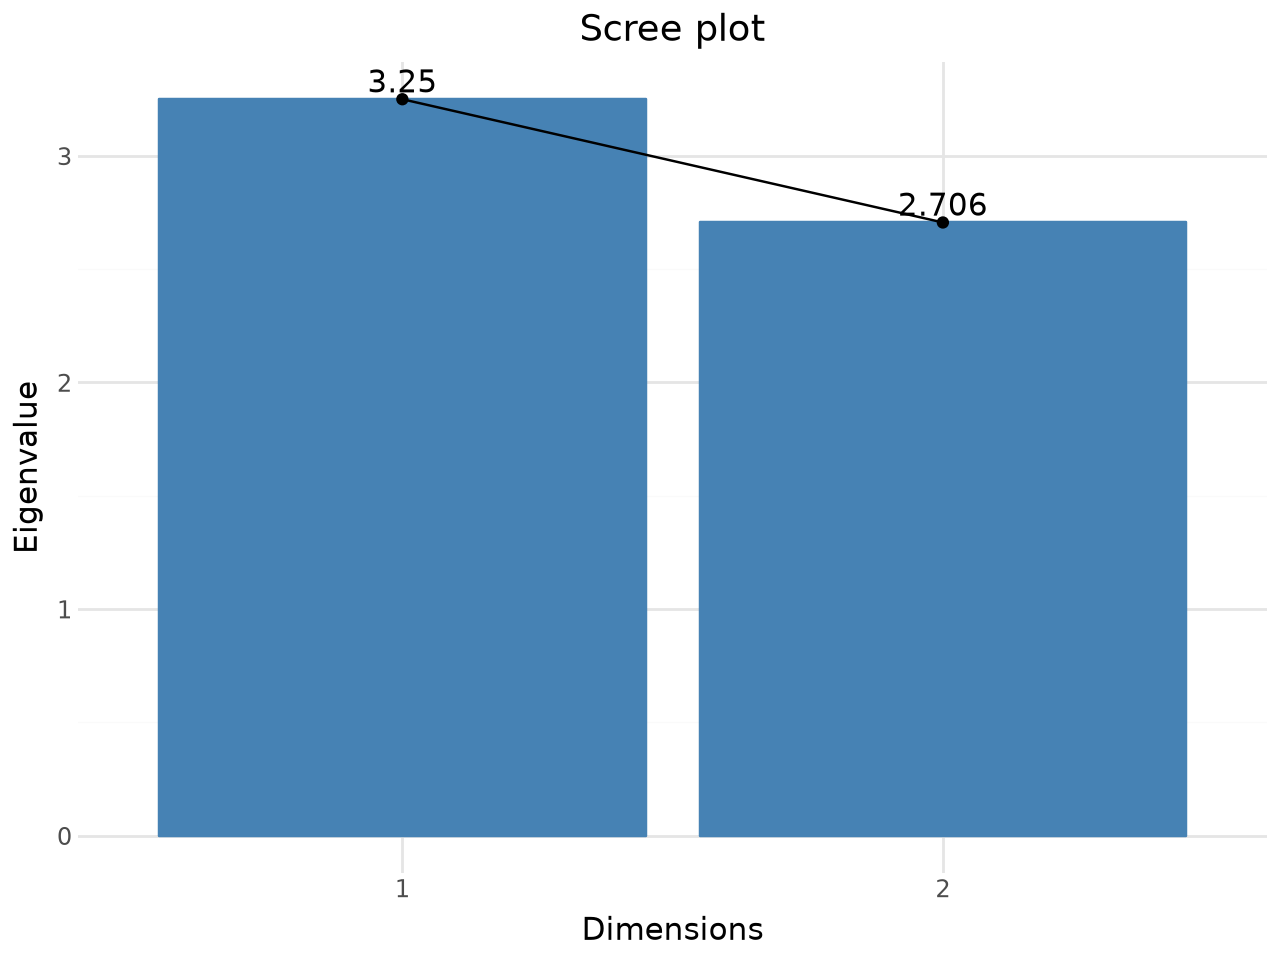

None


In [8]:
# screeplot
p = fviz_screeplot(
    obj = clf,
    choice = "eigenvalue",
    show_labels = True
)
print(p.show())

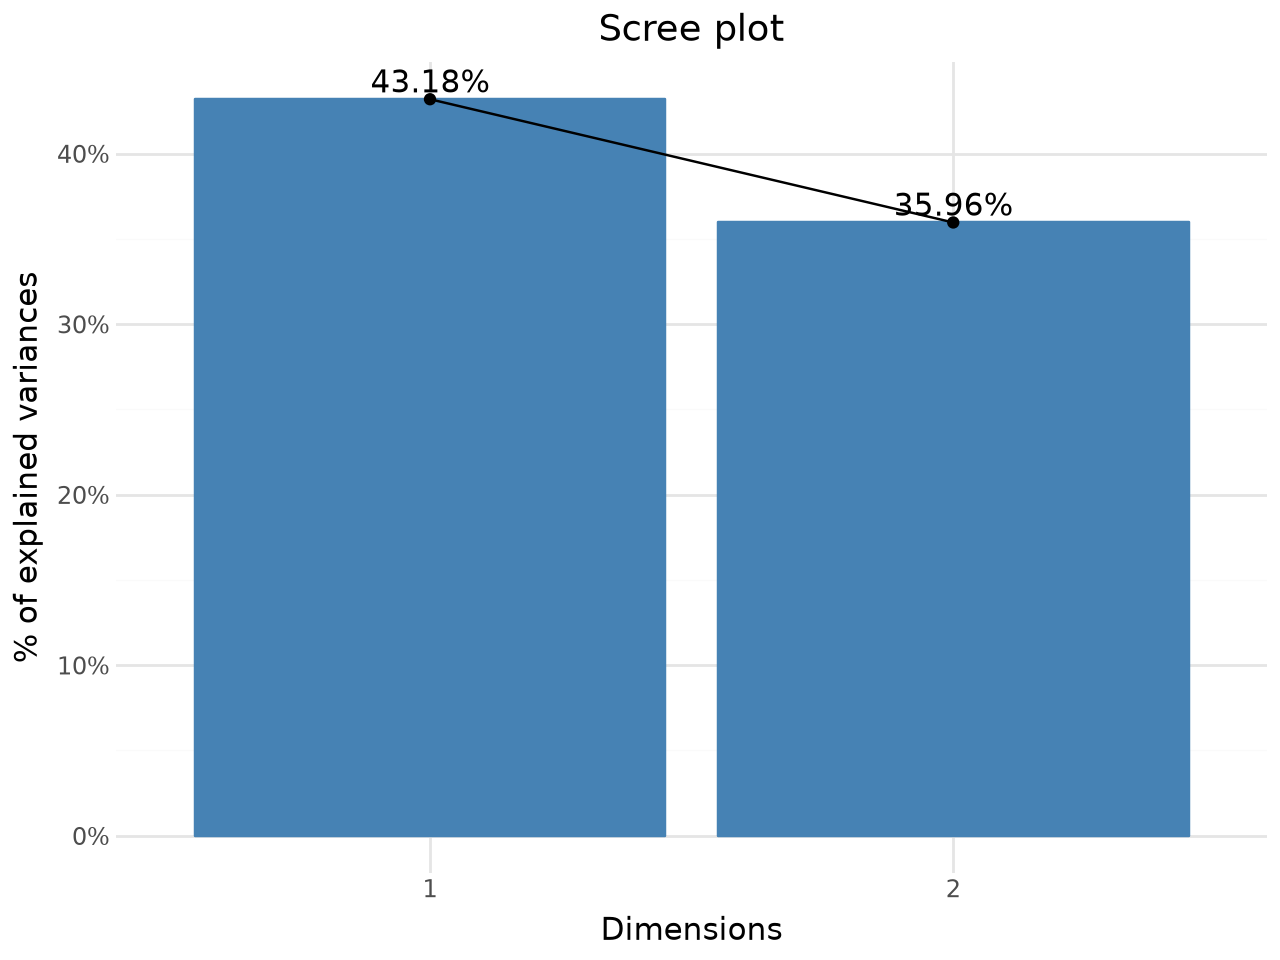

None


In [9]:
# proportion of variance
p = fviz_screeplot(
    obj = clf,
    choice = "proportion",
    show_labels = True
)
print(p.show())

## Variables

In [10]:
#variables
from scientisttools import get_fa
quanti_var = get_fa(clf,"var")
quanti_var._fields

('coord', 'contrib', 'infos')

### Variables coordinates (=loadings)

In [11]:
#variables coordinates (=loadings)
quanti_var.coord

,Dim1,Dim2
cost,-0.524419,-0.801165
size,-0.240428,-0.937866
alcohol,-0.604929,-0.730654
reputat,0.697277,-0.130379
color,-0.882431,0.202955
aroma,-0.762359,0.511455
taste,-0.800948,0.525726
rnd1,-0.022322,-0.208784
rnd2,-0.029304,0.060150
rnd3,-0.085007,-0.031658


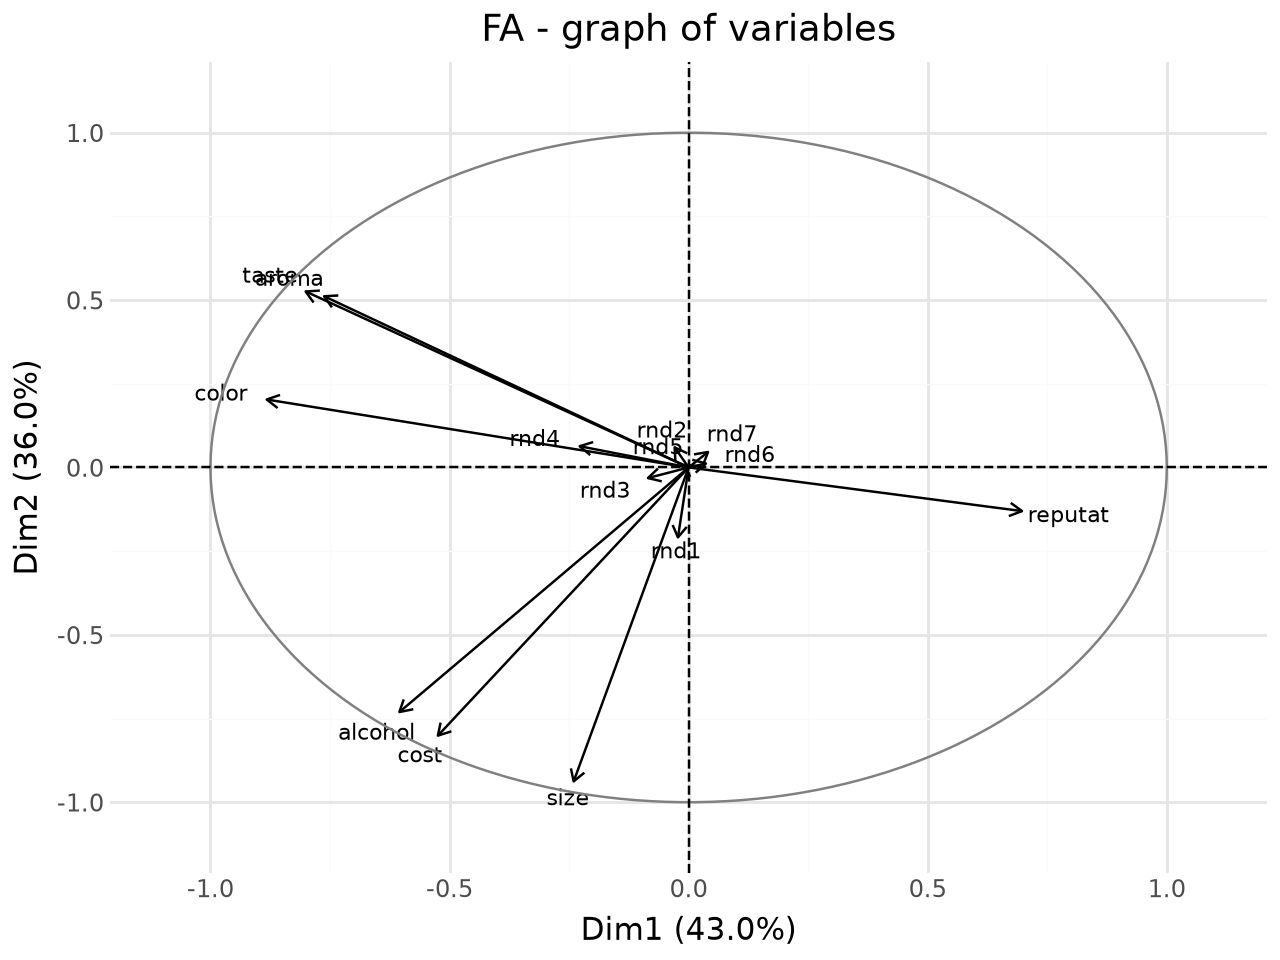

None


In [12]:
# correlation circle
from scientisttools import fviz_fa
p = fviz_fa(
    obj = clf,
    choice = "var",
    repel = True
)
print(p.show())

### Variables contributions

In [13]:
#variables contributions
quanti_var.contrib

,Dim1,Dim2
cost,0.997695,56.829868
size,7.545946,3.551357
alcohol,24.540740,0.308014
reputat,0.324076,1.044977
color,3.105774,0.395927
aroma,2.461003,0.007917
taste,60.719810,37.735007
rnd1,0.059657,0.039201
rnd2,0.000331,0.010016
rnd3,0.081684,0.009450


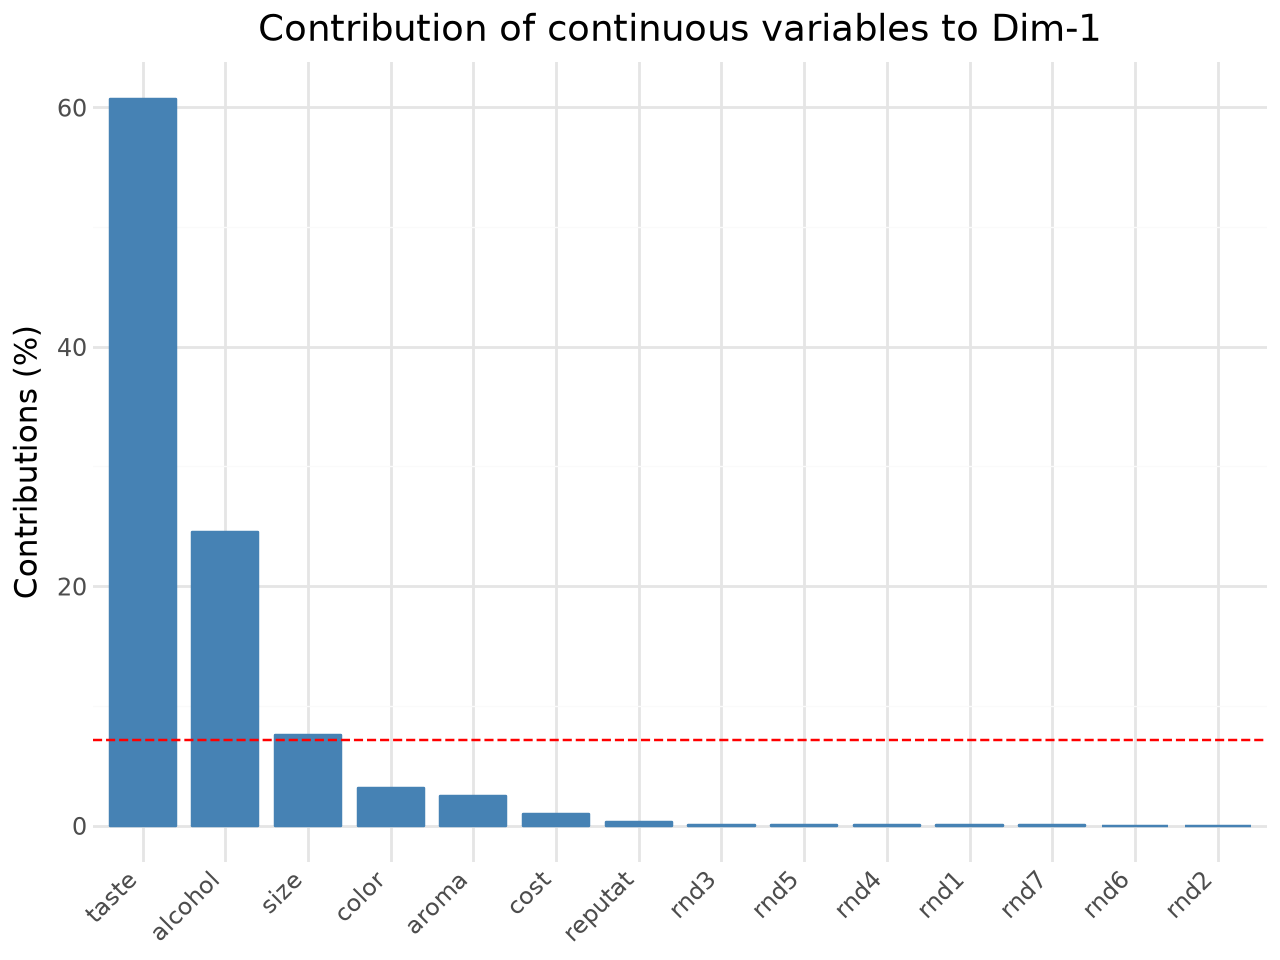

None


In [14]:
# contribution of continuous variables to Dim-1
from scientisttools import fviz_contrib
p = fviz_contrib(clf,"quanti_var")
print(p.show())

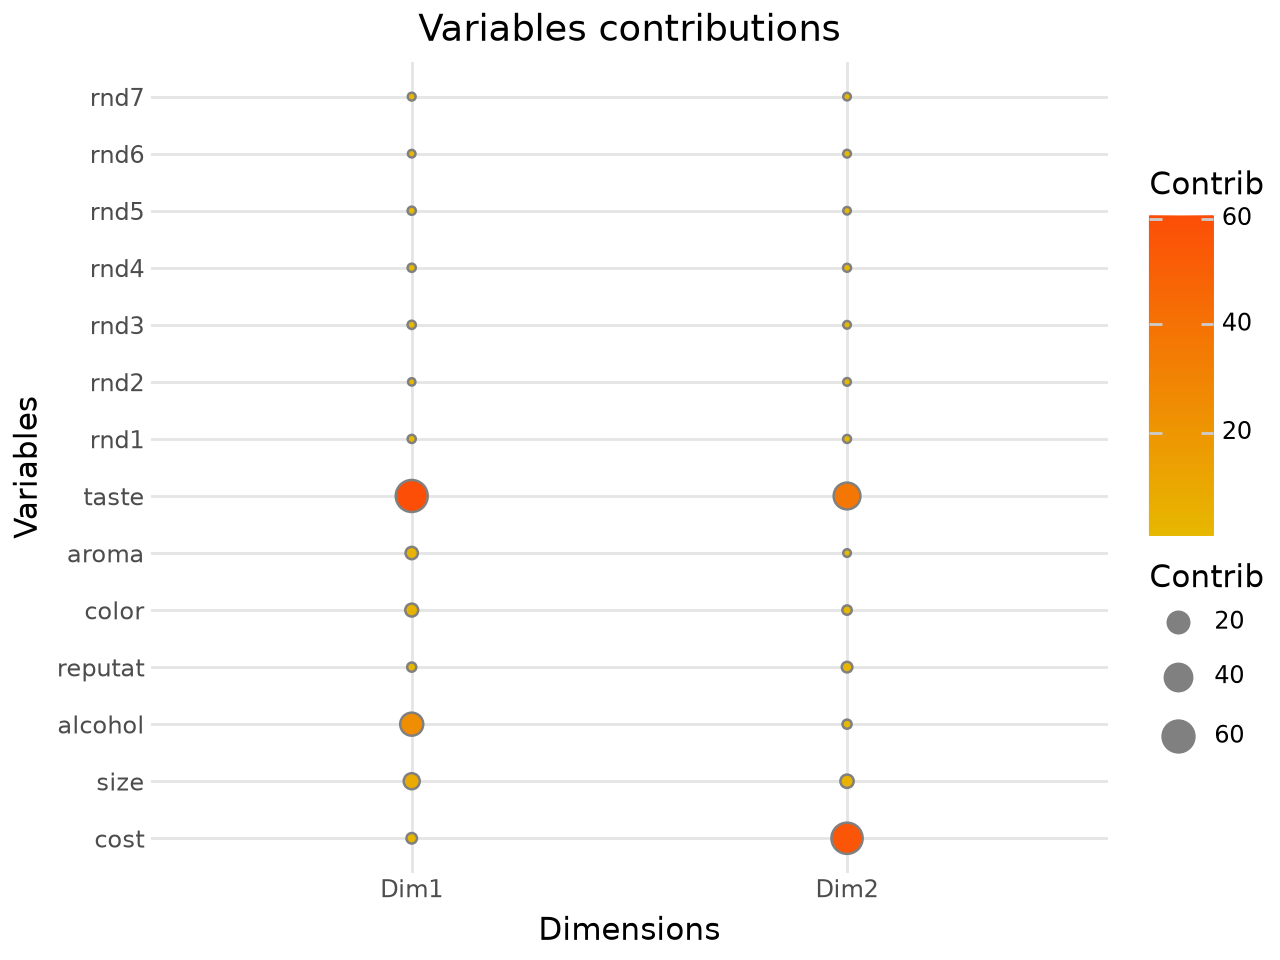

None


In [15]:
# variables contributions
from scientisttools import fviz_corrplot
p = fviz_corrplot(
    X = clf.quanti_var_.contrib,
    title="Variables contributions",
    legend_title="Contrib"
)
print(p.show())

### Variables additionals informations

In [16]:
# variables additionals informations
quanti_var.infos

,Weight,Prior,Final
cost,1.0,0.961050,0.916881
size,1.0,0.943887,0.937398
alcohol,1.0,0.912336,0.899795
reputat,1.0,0.772319,0.503194
color,1.0,0.853280,0.819875
aroma,1.0,0.886801,0.842777
taste,1.0,0.950270,0.917906
rnd1,1.0,0.138258,0.044089
rnd2,1.0,0.084953,0.004477
rnd3,1.0,0.073575,0.008228


## Individuals informations

In [17]:
# individuals informations
ind = get_fa(clf,"ind")
ind._fields

('coord',)

### Individuals coordinates

In [18]:
#individuals coordinates
ind.coord

,Dim1,Dim2
0,1.583010,-0.463331
1,-1.270464,-2.094575
2,-0.780689,-0.465390
3,-0.730639,1.295031
4,1.390544,-0.097260
...,...,...
94,1.314138,-0.101517
95,0.545964,-0.716173
96,0.234061,0.742089
97,0.098145,0.746268


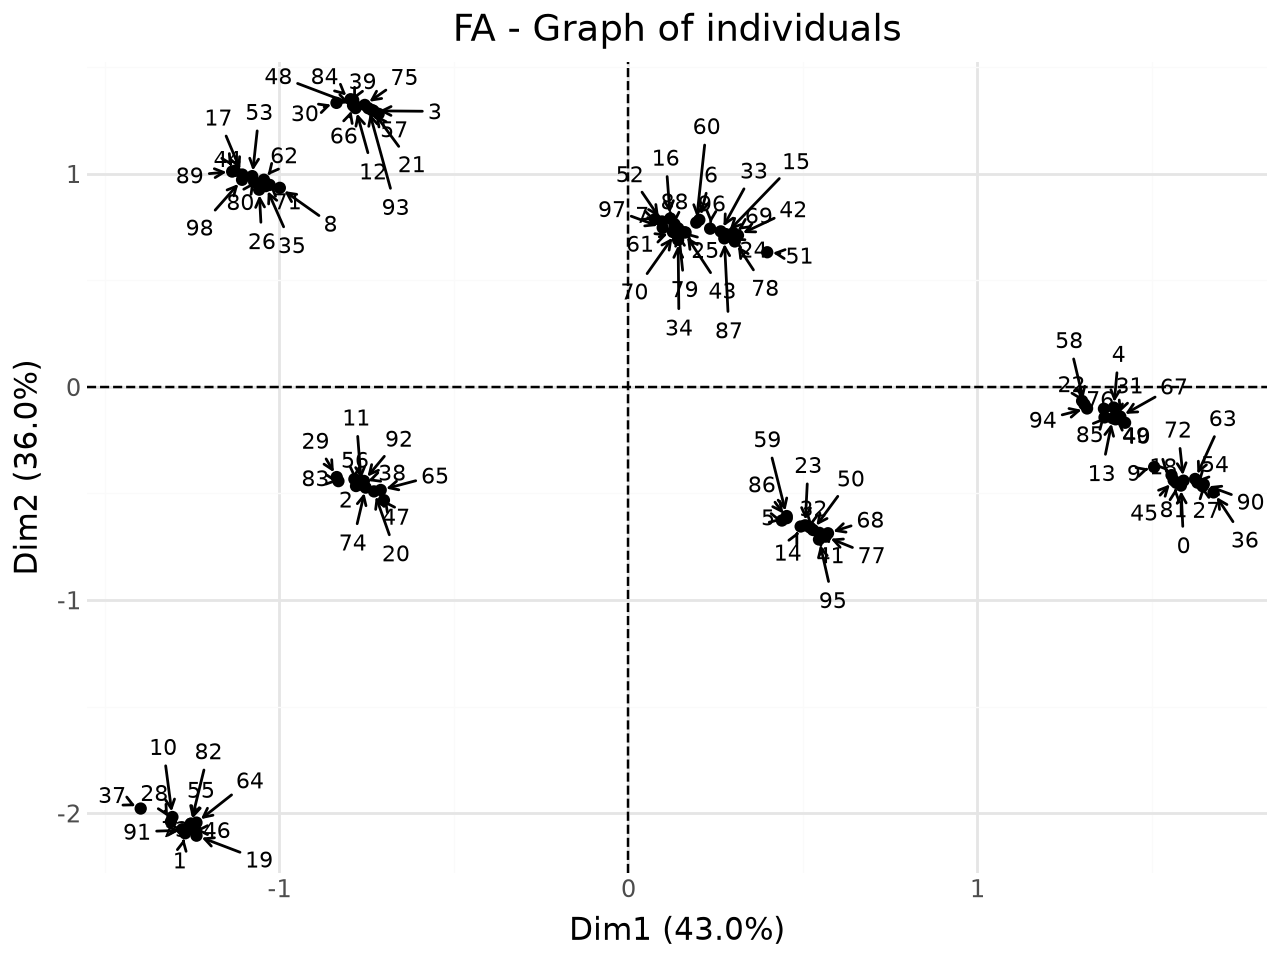

None


In [19]:
# individuals points
p = fviz_fa(
    obj = clf,
    choice = "ind",
    repel = True
)
print(p.show())

## Biplot

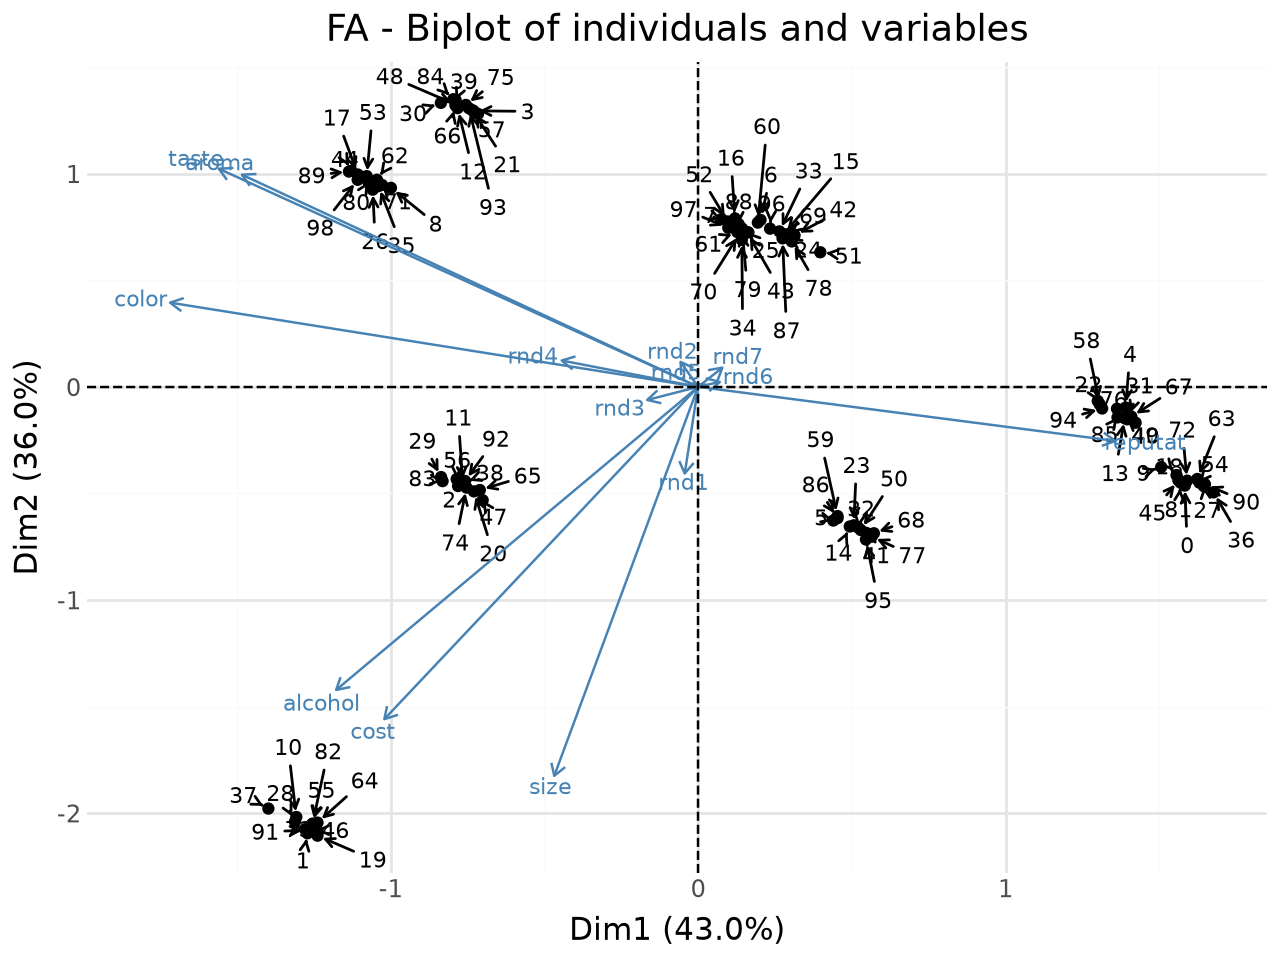

None


In [20]:
# biplot
p = fviz_fa(
    obj = clf,
    choice = "biplot",
    repel_ind = True,
    repel_var = True
)
print(p.show())

## Statistics with FA

In [21]:
# statistics for CA
from scientisttools import statsFA
stats = statsFA(clf)
stats._fields

('corr', 'others')

### Correlation

In [22]:
#correlation
corr = stats.corr
corr._fields

('corrcoef', 'pcorrcoef', 'reconst', 'residual')

#### Pearson correlation matrix

In [23]:
#pearson correlation matrox
corr.corrcoef

,cost,size,alcohol,reputat,color,aroma,taste,rnd1,rnd2,rnd3,rnd4,rnd5,rnd6,rnd7
cost,1.000000,0.878394,0.877019,-0.174783,0.320894,-0.027642,0.053982,0.166062,-0.051740,0.033018,0.101161,-0.001881,-0.022898,-0.062388
size,0.878394,1.000000,0.823668,-0.061234,0.014407,-0.286237,-0.307511,0.206038,-0.035755,0.059759,-0.021006,-0.038331,-0.000748,-0.026847
alcohol,0.877019,0.823668,1.000000,-0.360515,0.397697,0.097678,0.055805,0.182431,-0.028547,0.090211,0.076909,0.000802,-0.080030,-0.081195
reputat,-0.174783,-0.061234,-0.360515,1.000000,-0.523799,-0.521515,-0.626496,0.054200,0.053832,-0.097293,-0.150862,0.038719,-0.047220,0.090954
color,0.320894,0.014407,0.397697,-0.523799,1.000000,0.823244,0.804870,-0.014480,0.106898,0.061969,0.245058,0.024351,-0.085458,0.053949
aroma,-0.027642,-0.286237,0.097678,-0.521515,0.823244,1.000000,0.866073,-0.045175,0.067048,0.043716,0.151902,0.038739,-0.051204,-0.012857
taste,0.053982,-0.307511,0.055805,-0.626496,0.804870,0.866073,1.000000,-0.082160,0.034088,-0.003334,0.206091,-0.012485,0.027340,-0.041157
rnd1,0.166062,0.206038,0.182431,0.054200,-0.014480,-0.045175,-0.082160,1.000000,0.067112,-0.043945,-0.106403,0.187147,0.104980,-0.038058
rnd2,-0.051740,-0.035755,-0.028547,0.053832,0.106898,0.067048,0.034088,0.067112,1.000000,-0.013165,0.063579,0.067021,0.056613,0.070214
rnd3,0.033018,0.059759,0.090211,-0.097293,0.061969,0.043716,-0.003334,-0.043945,-0.013165,1.000000,0.156839,-0.073910,0.071880,0.014219


#### Partial pearson correlation matrix

In [24]:
#partial pearson correlation matrox
corr.pcorrcoef

,cost,size,alcohol,reputat,color,aroma,taste,rnd1,rnd2,rnd3,rnd4,rnd5,rnd6,rnd7
cost,1.000000,0.820162,0.606899,0.695902,0.041644,-0.604287,0.796466,-0.112835,-0.171570,-0.011951,0.134970,0.185414,-0.019552,-0.071346
size,0.820162,1.000000,-0.124221,-0.522308,-0.078193,0.398832,-0.672197,0.117718,0.149532,0.002381,-0.125876,-0.193811,0.089426,0.114562
alcohol,0.606899,-0.124221,1.000000,-0.632505,0.322078,0.402476,-0.592952,0.133218,0.047764,0.012310,-0.072889,-0.083627,-0.082374,-0.104707
reputat,0.695902,-0.522308,-0.632505,1.000000,0.160328,0.416750,-0.767395,0.144765,0.142295,-0.067045,-0.101510,-0.125778,-0.027657,0.032215
color,0.041644,-0.078193,0.322078,0.160328,1.000000,0.352250,0.269313,-0.046095,0.157291,0.048110,0.119991,-0.005908,-0.090712,0.230538
aroma,-0.604287,0.398832,0.402476,0.416750,0.352250,1.000000,0.668571,-0.028785,-0.100662,0.064347,-0.034785,0.161202,-0.056172,-0.070665
taste,0.796466,-0.672197,-0.592952,-0.767395,0.269313,0.668571,1.000000,0.099868,0.082736,-0.088281,-0.059324,-0.193950,0.105593,-0.028986
rnd1,-0.112835,0.117718,0.133218,0.144765,-0.046095,-0.028785,0.099868,1.000000,0.042474,-0.031680,-0.091187,0.219977,0.132345,-0.024035
rnd2,-0.171570,0.149532,0.047764,0.142295,0.157291,-0.100662,0.082736,0.042474,1.000000,-0.028028,0.067000,0.072015,0.077198,0.009493
rnd3,-0.011951,0.002381,0.012310,-0.067045,0.048110,0.064347,-0.088281,-0.031680,-0.028028,1.000000,0.161500,-0.080395,0.098288,-0.001235


#### Reproduced correlation matrix

In [25]:
#reproduced correlation matrox
corr.reconst

,cost,size,alcohol,reputat,color,aroma,taste,rnd1,rnd2,rnd3,rnd4,rnd5,rnd6,rnd7
cost,0.916881,0.877470,0.902611,-0.261210,0.300163,-0.009964,-0.001161,0.178976,-0.032822,0.069943,0.068740,-0.002431,-0.028481,-0.058335
size,0.877470,0.937398,0.830697,-0.045367,0.021817,-0.296383,-0.300490,0.201178,-0.049367,0.050129,-0.004667,-0.005996,-0.019796,-0.053129
alcohol,0.902611,0.830697,0.899795,-0.326542,0.385519,0.087477,0.100393,0.166052,-0.026222,0.074554,0.091564,-0.001149,-0.030568,-0.058342
reputat,-0.261210,-0.045367,-0.326542,0.503194,-0.641760,-0.598258,-0.627026,0.011657,-0.028275,-0.055146,-0.167219,-0.006997,0.023748,0.022273
color,0.300163,0.021817,0.385519,-0.641760,0.819875,0.776532,0.813480,-0.022676,0.038067,0.068588,0.214029,0.009180,-0.029606,-0.026432
aroma,-0.009964,-0.296383,0.087477,-0.598258,0.776532,0.842777,0.879495,-0.089766,0.053104,0.048614,0.206221,0.010806,-0.021608,-0.007293
taste,-0.001161,-0.300490,0.100393,-0.627026,0.813480,0.879495,0.917906,-0.091885,0.055094,0.051443,0.215923,0.011254,-0.022839,-0.008199
rnd1,0.178976,0.201178,0.166052,0.011657,-0.022676,-0.089766,-0.091885,0.044089,-0.011904,0.008507,-0.008152,-0.001598,-0.003275,-0.010561
rnd2,-0.032822,-0.049367,-0.026222,-0.028275,0.038067,0.053104,0.055094,-0.011904,0.004477,0.000587,0.010495,0.000762,-0.000352,0.001592
rnd3,0.069943,0.050129,0.074554,-0.055146,0.068588,0.048614,0.051443,0.008507,0.000587,0.008228,0.017371,0.000446,-0.003457,-0.004914


#### Residual correlation matrix

In [26]:
#residual correlation matrox
corr.residual

,cost,size,alcohol,reputat,color,aroma,taste,rnd1,rnd2,rnd3,rnd4,rnd5,rnd6,rnd7
cost,NaN,0.000924,-0.025592,0.086427,0.020731,-0.017678,0.055143,-0.012914,-0.018917,-0.036925,0.032422,0.000550,0.005583,-0.004053
size,0.000924,NaN,-0.007029,-0.015866,-0.007410,0.010146,-0.007021,0.004859,0.013612,0.009629,-0.016338,-0.032335,0.019048,0.026282
alcohol,-0.025592,-0.007029,NaN,-0.033973,0.012178,0.010201,-0.044588,0.016380,-0.002325,0.015656,-0.014656,0.001951,-0.049462,-0.022853
reputat,0.086427,-0.015866,-0.033973,NaN,0.117961,0.076743,0.000531,0.042543,0.082107,-0.042147,0.016357,0.045716,-0.070968,0.068681
color,0.020731,-0.007410,0.012178,0.117961,NaN,0.046712,-0.008611,0.008196,0.068831,-0.006619,0.031029,0.015172,-0.055852,0.080381
aroma,-0.017678,0.010146,0.010201,0.076743,0.046712,NaN,-0.013422,0.044591,0.013943,-0.004898,-0.054319,0.027933,-0.029596,-0.005564
taste,0.055143,-0.007021,-0.044588,0.000531,-0.008611,-0.013422,NaN,0.009725,-0.021005,-0.054777,-0.009832,-0.023739,0.050179,-0.032958
rnd1,-0.012914,0.004859,0.016380,0.042543,0.008196,0.044591,0.009725,NaN,0.079017,-0.052453,-0.098251,0.188745,0.108256,-0.027497
rnd2,-0.018917,0.013612,-0.002325,0.082107,0.068831,0.013943,-0.021005,0.079017,NaN,-0.013752,0.053084,0.066259,0.056965,0.068622
rnd3,-0.036925,0.009629,0.015656,-0.042147,-0.006619,-0.004898,-0.054777,-0.052453,-0.013752,NaN,0.139469,-0.074356,0.075337,0.019133


### Others statistics

In [27]:
# others statistics
others = stats.others
others._fields

('vaccounted', 'explained_variance', 'communalities', 'inertia')

#### Variances accounted

In [28]:
#variances accounted
others.vaccounted

,Dim1,Dim2
Original,3.386557,2.794665
Common,3.249932,2.706060
SS loadings,3.249932,2.706060
Proportion Var (%),23.213802,19.328998
Cumulative Var (%),23.213802,42.542799
Proportion Explained (%),54.565760,45.434240
Cumulative Proportion (%),54.565760,100.000000


#### Explained variance

In [29]:
# explained variance
others.explained_variance

,Weighted,Unweighted,R2
Dim1,3.249932,3.249932,0.973575
Dim2,2.706060,2.706060,0.982389


#### Communalities

In [30]:
#communalities
round(others.communalities,4)

5.956

#### Inertia

In [31]:
#inertia
round(others.inertia,4)

7.0137

## Others elements

### summary

In [32]:
# summary
from scientisttools import summary
summary(clf)

                     Factor Analysis - Results                     

Importance of components:
      Eigenvalue  Difference  Proportion (%)  Cumulative (%)
Dim1      3.2499      0.5439         43.1847         43.1847
Dim2      2.7061      2.2005         35.9578         79.1425

Individuals (the 10 first):
     Dim1    Dim2
0  1.5830 -0.4633
1 -1.2705 -2.0946
2 -0.7807 -0.4654
3 -0.7306  1.2950
4  1.3905 -0.0973
5  0.4396 -0.6272
6  0.2030  0.7835
7  0.0763  0.7870
8 -0.9991  0.9336
9  1.5064 -0.3763

Continuous (the 10 first):
           Dim1      ctr    Dim2      ctr
cost    -0.5244   0.9977 -0.8012  56.8299
size    -0.2404   7.5459 -0.9379   3.5514
alcohol -0.6049  24.5407 -0.7307   0.3080
reputat  0.6973   0.3241 -0.1304   1.0450
color   -0.8824   3.1058  0.2030   0.3959
aroma   -0.7624   2.4610  0.5115   0.0079
taste   -0.8009  60.7198  0.5257  37.7350
rnd1    -0.0223   0.0597 -0.2088   0.0392
rnd2    -0.0293   0.0003  0.0602   0.0100
rnd3    -0.0850   0.0817 -0.0317   0.0094
